In [1]:
#Import dependencies

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:


data_add = "../data/marketing_data_cleaned.xlsx"



df = pd.read_excel(data_add)



# ROAS = Revenue / Spend
df["ROAS"] = np.where(
    df["Spend"] != 0,
    df["Revenue"] / df["Spend"],
    np.nan
)

# CTR = Clicks / Impressions
df["CTR"] = np.where(
    df["Impressions"] != 0,
    df["Clicks"] / df["Impressions"],
    np.nan
)

# CVR = Purchases / Clicks
df["CVR"] = np.where(
    df["Clicks"] != 0,
    df["Purchases"] / df["Clicks"],
    np.nan
)

# CPC = Spend / Clicks
df["CPC"] = np.where(
    df["Clicks"] != 0,
    df["Spend"] / df["Clicks"],
    np.nan
)

# (Optional) Round for readability
df["ROAS"] = df["ROAS"].round(4)
df["CTR"] = df["CTR"].round(4)
df["CVR"] = df["CVR"].round(4)
df["CPC"] = df["CPC"].round(4)




# Month number (1=January, ..., 12=December)
df["Month"] = df["Date"].dt.month

# ISO Week of the year (1-52 or 53)
df["Week"] = df["Date"].dt.isocalendar().week

# Day of the week (Monday=0, Tuesday=1, ..., Sunday=6)
df["Day_of_Week"] = df["Date"].dt.dayofweek

# Day of the month (1-31)
df["Day"] = df["Date"].dt.day

df.head()


,Date,Platform,Campaign,Region,Spend,CPM,Impressions,Frequency,Clicks,Purchases,...,Calculated_CPM,campaign_id,ROAS,CTR,CVR,CPC,Month,Week,Day_of_Week,Day
0,2024-01-01,FB,FB_Athletes_Video_Protein_001,West,1187.29,18.0,65960,2.75,527,15,...,18.000152,1,1.0248,0.0080,0.0285,2.2529,1,1,0,1
1,2024-01-01,FB,FB_Athletes_Video_Protein_001,South,1081.89,18.0,60105,2.51,512,12,...,18.000000,1,0.8024,0.0085,0.0234,2.1131,1,1,0,1
2,2024-01-01,FB,FB_Athletes_Video_Protein_001,Northeast,648.47,18.0,36025,2.52,344,9,...,18.000555,1,1.0713,0.0095,0.0262,1.8851,1,1,0,1
3,2024-01-01,FB,FB_Athletes_Video_Protein_001,Midwest,463.38,18.0,25743,2.49,272,6,...,18.000233,1,1.0416,0.0106,0.0221,1.7036,1,1,0,1
4,2024-01-01,FB,FB_Athletes_Image_Preworkout_002,West,800.59,18.0,44477,3.10,418,14,...,18.000090,2,1.0645,0.0094,0.0335,1.9153,1,1,0,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3173 entries, 0 to 3172
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   3173 non-null   datetime64[ns]
 1   Platform               3173 non-null   object        
 2   Campaign               3173 non-null   object        
 3   Region                 3173 non-null   object        
 4   Spend                  3173 non-null   float64       
 5   CPM                    3173 non-null   float64       
 6   Impressions            3173 non-null   int64         
 7   Frequency              3173 non-null   float64       
 8   Clicks                 3173 non-null   int64         
 9   Purchases              3173 non-null   int64         
 10  Revenue                3173 non-null   float64       
 11  Product_Category       3173 non-null   object        
 12  Target_Audience        3173 non-null   object        
 13  Cre

In [4]:
df[df['Clicks'] == 0].head(20)

,Date,Platform,Campaign,Region,Spend,CPM,Impressions,Frequency,Clicks,Purchases,...,Calculated_CPM,campaign_id,ROAS,CTR,CVR,CPC,Month,Week,Day_of_Week,Day
85,2024-01-03,Google,Google_Athletes_Search_Protein_001,Northeast,1303.24,15.03,86709,2.61,0,41,...,15.030043,1,2.7571,0.0,NaN,NaN,1,1,2,3
91,2024-01-03,Google,Google_FitnessEnth_Display_Preworkout_001,West,469.88,15.03,31262,2.57,0,13,...,15.030388,1,1.5221,0.0,NaN,NaN,1,1,2,3
93,2024-01-03,Google,Google_FitnessEnth_Display_Preworkout_001,Northeast,921.64,15.03,61320,3.77,0,12,...,15.030007,1,0.7501,0.0,NaN,NaN,1,1,2,3
121,2024-01-04,Google,Google_Athletes_Search_Protein_001,Northeast,642.88,15.04,42730,3.42,0,16,...,15.045167,1,2.1599,0.0,NaN,NaN,1,1,3,4
159,2024-01-05,Google,Google_WeightLoss_Search_Diet_001,West,1508.80,15.06,100186,3.79,0,47,...,15.059988,1,1.8598,0.0,NaN,NaN,1,1,4,5
161,2024-01-05,Google,Google_WeightLoss_Search_Diet_001,Northeast,1576.44,15.06,104677,2.88,0,70,...,15.060042,1,2.8131,0.0,NaN,NaN,1,1,4,5
200,2024-01-06,Google,Google_FitnessEnth_Display_Preworkout_001,Midwest,436.89,18.09,24150,2.75,0,5,...,18.090683,1,0.6409,0.0,NaN,NaN,1,1,5,6
227,2024-01-07,Google,Google_Athletes_Search_Protein_001,Northeast,1076.51,18.11,59449,3.86,0,34,...,18.108126,1,2.3948,0.0,NaN,NaN,1,1,6,7
297,2024-01-09,Google,Google_Athletes_Search_Protein_001,Northeast,969.32,15.12,64108,2.73,0,33,...,15.120110,1,2.6236,0.0,NaN,NaN,1,2,1,9
304,2024-01-09,Google,Google_FitnessEnth_Display_Preworkout_001,South,516.06,15.12,34130,3.16,0,9,...,15.120422,1,0.9701,0.0,NaN,NaN,1,2,1,9


In [37]:
import pandas as pd
import numpy as np

from scipy.stats import (
    shapiro,
    levene,
    f_oneway,
    kruskal
)

from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scikit_posthocs as sp


def compare_groups(df, group_col, metrics=None, alpha=0.05):
    """
    Compare multiple metrics across a categorical variable.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataset.

    group_col : str
        Categorical column to compare
        (e.g. 'Platform', 'Region', 'Creative_Type').

    metrics : list[str], optional
        Metrics to analyze.
        Default = ["ROAS", "CTR", "CVR", "CPC"]

    alpha : float
        Significance level.
    """

    if metrics is None:
        metrics = ["ROAS", "CTR", "CVR", "CPC"]

    groups_names = df[group_col].dropna().unique()

    for metric in metrics:

        print("=" * 80)
        print(f"{metric} by {group_col}")
        print("=" * 80)

        # -------------------------------------------------------------
        # Descriptive statistics
        # -------------------------------------------------------------

        summary = (
            df.groupby(group_col)[metric]
            .agg(["mean", "median", "std", "count"])
        )

        summary = summary[summary["count"] > 0]
        summary = summary.round(4)

        print("\nDescriptive Statistics")
        print(summary)

        # -------------------------------------------------------------
        # Gather groups
        # -------------------------------------------------------------

        groups = []
        valid_group_names = []

        for g in groups_names:

            values = df.loc[df[group_col] == g, metric].dropna()

            if len(values) > 0:
                groups.append(values)
                valid_group_names.append(g)

        # -------------------------------------------------------------
        # Shapiro-Wilk
        # -------------------------------------------------------------

        normal = True

        print("\nShapiro-Wilk Test")

        for name, values in zip(valid_group_names, groups):

            if len(values) >= 3:

                _, pvalue = shapiro(values)

                print(f"{name:<20} p = {pvalue:.4f}")

                if pvalue < alpha:
                    normal = False

        # -------------------------------------------------------------
        # Levene
        # -------------------------------------------------------------

        _, lev_p = levene(*groups)

        equal_var = lev_p >= alpha

        print(f"\nLevene Test p = {lev_p:.4f}")

        # -------------------------------------------------------------
        # Parametric / Non-parametric
        # -------------------------------------------------------------

        if normal and equal_var:

            print("\nUsing One-Way ANOVA")

            stat, p = f_oneway(*groups)

            print(f"F = {stat:.4f}")
            print(f"p = {p:.6f}")

            if p < alpha:

                print("\nSignificant differences detected.")

                tukey = pairwise_tukeyhsd(
                    endog=df[metric],
                    groups=df[group_col],
                    alpha=alpha
                )

                print("\nTukey HSD")
                print(tukey)

            else:

                print("\nNo statistically significant differences.")

        else:

            print("\nUsing Kruskal-Wallis Test")

            stat, p = kruskal(*groups)

            print(f"H = {stat:.4f}")
            print(f"p = {p:.6f}")

            if p < alpha:

                print("\nSignificant differences detected.")

                dunn = sp.posthoc_dunn(
                    df[[group_col, metric]].dropna(),
                    val_col=metric,
                    group_col=group_col,
                    p_adjust="bonferroni"
                )

                print("\nDunn Post-hoc Test")
                print(dunn.round(4))

            else:

                print("\nNo statistically significant differences.")

        # -------------------------------------------------------------
        # Business Summary
        # -------------------------------------------------------------

        best = summary["mean"].idxmax()
        worst = summary["mean"].idxmin()

        print("\nBusiness Summary")
        print("-" * 28)

        print(
            f"The highest average {metric} was achieved by "
            f"{best} ({summary.loc[best,'mean']:.4f})."
        )

        print(
            f"The lowest average {metric} was observed for "
            f"{worst} ({summary.loc[worst,'mean']:.4f})."
        )

        if p < alpha:

            print(
                f"Differences between {group_col.lower()}s "
                f"are statistically significant (p < {alpha})."
            )

        else:

            print(
                f"No statistically significant differences were found "
                f"between {group_col.lower()}s (p ≥ {alpha})."
            )

        print("\n\n")

In [38]:
compare_groups(df, "Platform", metrics=["Video_Completion_Rate"])

Video_Completion_Rate by Platform

Descriptive Statistics
            mean  median     std  count
Platform                               
FB        0.4430  0.4442  0.0250    299
TT        0.6195  0.6163  0.0581    908

Shapiro-Wilk Test
FB                   p = 0.0000
TT                   p = 0.0000

Levene Test p = 0.0000

Using Kruskal-Wallis Test
H = 674.2412
p = 0.000000

Significant differences detected.

Dunn Post-hoc Test
     FB   TT
FB  1.0  0.0
TT  0.0  1.0

Business Summary
----------------------------
The highest average Video_Completion_Rate was achieved by TT (0.6195).
The lowest average Video_Completion_Rate was observed for FB (0.4430).
Differences between platforms are statistically significant (p < 0.05).





In [39]:
compare_groups(df[df['Platform']=='TT'], "Product_Category", metrics=["Video_Completion_Rate"])

Video_Completion_Rate by Product_Category

Descriptive Statistics
                    mean  median     std  count
Product_Category                               
Diet              0.5618  0.5619  0.0320    293
Preworkout        0.6181  0.6181  0.0349    300
Protein           0.6745  0.6758  0.0387    315

Shapiro-Wilk Test
Protein              p = 0.0000
Preworkout           p = 0.0000
Diet                 p = 0.0000

Levene Test p = 0.0001

Using Kruskal-Wallis Test
H = 587.1425
p = 0.000000

Significant differences detected.

Dunn Post-hoc Test
            Diet  Preworkout  Protein
Diet         1.0         0.0      0.0
Preworkout   0.0         1.0      0.0
Protein      0.0         0.0      1.0

Business Summary
----------------------------
The highest average Video_Completion_Rate was achieved by Protein (0.6745).
The lowest average Video_Completion_Rate was observed for Diet (0.5618).
Differences between product_categorys are statistically significant (p < 0.05).





In [40]:
compare_groups(df[df['Platform']=='TT'], "Region", metrics=["Video_Completion_Rate"])

Video_Completion_Rate by Region

Descriptive Statistics
             mean  median     std  count
Region                                  
Midwest    0.6206  0.6188  0.0584    220
Northeast  0.6191  0.6165  0.0578    229
South      0.6199  0.6160  0.0587    228
West       0.6184  0.6140  0.0580    231

Shapiro-Wilk Test
West                 p = 0.0065
South                p = 0.0028
Northeast            p = 0.0090
Midwest              p = 0.0096

Levene Test p = 0.9766

Using Kruskal-Wallis Test
H = 0.1893
p = 0.979302

No statistically significant differences.

Business Summary
----------------------------
The highest average Video_Completion_Rate was achieved by Midwest (0.6206).
The lowest average Video_Completion_Rate was observed for West (0.6184).
No statistically significant differences were found between regions (p ≥ 0.05).





In [42]:
compare_groups(df[df['Platform']=='TT'], "Is_Competitive_Event", metrics=["Video_Completion_Rate"])

Video_Completion_Rate by Is_Competitive_Event

Descriptive Statistics
                        mean  median    std  count
Is_Competitive_Event                              
False                 0.6189  0.6152  0.058    872
True                  0.6335  0.6195  0.061     36

Shapiro-Wilk Test
1                    p = 0.0273
0                    p = 0.0000

Levene Test p = 0.9008

Using Kruskal-Wallis Test
H = 1.5983
p = 0.206148

No statistically significant differences.

Business Summary
----------------------------
The highest average Video_Completion_Rate was achieved by True (0.6335).
The lowest average Video_Completion_Rate was observed for False (0.6189).
No statistically significant differences were found between is_competitive_events (p ≥ 0.05).





In [36]:
compare_groups(df, "Platform")

ROAS by Platform

Descriptive Statistics
            mean  median     std  count
Platform                               
FB        0.8162  0.7499  0.4225   1054
Google    1.1057  0.9456  0.6495   1053
TT        0.9602  0.8625  0.4950   1066

Shapiro-Wilk Test
FB                   p = 0.0000
Google               p = 0.0000
TT                   p = 0.0000

Levene Test p = 0.0000

Using Kruskal-Wallis Test
H = 106.6989
p = 0.000000

Significant differences detected.

Dunn Post-hoc Test
         FB  Google      TT
FB      1.0  0.0000  0.0000
Google  0.0  1.0000  0.0002
TT      0.0  0.0002  1.0000

Business Summary
----------------------------
The highest average ROAS was achieved by Google (1.1057).
The lowest average ROAS was observed for FB (0.8162).
Differences between platforms are statistically significant (p < 0.05).



CTR by Platform

Descriptive Statistics
            mean  median     std  count
Platform                               
FB        0.0057  0.0056  0.0021   1054
Google

In [7]:
compare_groups(df, "Region")

ROAS by Region

Descriptive Statistics
             mean  median     std  count
Region                                  
Midwest    0.8337  0.6951  0.4940    760
Northeast  1.0330  0.8678  0.5960    803
South      0.9605  0.8535  0.4868    803
West       1.0083  0.8915  0.5662    807

Shapiro-Wilk Test
West                 p = 0.0000
South                p = 0.0000
Northeast            p = 0.0000
Midwest              p = 0.0000

Levene Test p = 0.0000

Using Kruskal-Wallis Test
H = 69.2321
p = 0.000000

Significant differences detected.

Dunn Post-hoc Test
           Midwest  Northeast  South  West
Midwest        1.0        0.0    0.0   0.0
Northeast      0.0        1.0    1.0   1.0
South          0.0        1.0    1.0   1.0
West           0.0        1.0    1.0   1.0

Business Summary
----------------------------
The highest average ROAS was achieved by Northeast (1.0330).
The lowest average ROAS was observed for Midwest (0.8337).
Differences between regions are statistically significa

In [8]:
compare_groups(df, "Audience_Product")

ROAS by Audience_Product

Descriptive Statistics
                          mean  median     std  count
Audience_Product                                     
Athletes_Preworkout     0.6176  0.5656  0.2749    349
Athletes_Protein        1.3059  1.1981  0.5542   1054
FitnessEnth_Preworkout  0.6189  0.5754  0.2404    704
FitnessEnth_WeightLoss  0.7560  0.6572  0.4480    355
WeightLoss_Diet         1.0578  0.9574  0.5374    711

Shapiro-Wilk Test
Athletes_Protein     p = 0.0000
Athletes_Preworkout  p = 0.0000
FitnessEnth_WeightLoss p = 0.0000
WeightLoss_Diet      p = 0.0000
FitnessEnth_Preworkout p = 0.0000

Levene Test p = 0.0000

Using Kruskal-Wallis Test
H = 1089.1785
p = 0.000000

Significant differences detected.

Dunn Post-hoc Test
                        Athletes_Preworkout  Athletes_Protein  \
Athletes_Preworkout                  1.0000               0.0   
Athletes_Protein                     0.0000               1.0   
FitnessEnth_Preworkout               1.0000               0.0 

In [9]:
compare_groups(df, "Target_Audience")

ROAS by Target_Audience

Descriptive Statistics
                   mean  median     std  count
Target_Audience                               
Athletes         1.1347  1.0448  0.5814   1403
FitnessEnth      0.6648  0.6022  0.3313   1059
WeightLoss       1.0578  0.9574  0.5374    711

Shapiro-Wilk Test
Athletes             p = 0.0000
FitnessEnth          p = 0.0000
WeightLoss           p = 0.0000

Levene Test p = 0.0000

Using Kruskal-Wallis Test
H = 566.6095
p = 0.000000

Significant differences detected.

Dunn Post-hoc Test
             Athletes  FitnessEnth  WeightLoss
Athletes       1.0000          0.0      0.0122
FitnessEnth    0.0000          1.0      0.0000
WeightLoss     0.0122          0.0      1.0000

Business Summary
----------------------------
The highest average ROAS was achieved by Athletes (1.1347).
The lowest average ROAS was observed for FitnessEnth (0.6648).
Differences between target_audiences are statistically significant (p < 0.05).



CTR by Target_Audience

Descri

In [10]:
compare_groups(df, "Creative_Type")

ROAS by Creative_Type

Descriptive Statistics
                 mean  median     std  count
Creative_Type                               
Carousel       0.7560  0.6572  0.4480    355
Display        0.6626  0.6194  0.2685    348
Image          0.6176  0.5656  0.2749    349
Search         1.3244  1.2455  0.6708    705
Video          0.9886  0.9058  0.4730   1416

Shapiro-Wilk Test
Video                p = 0.0000
Image                p = 0.0000
Carousel             p = 0.0000
Search               p = 0.0000
Display              p = 0.0000

Levene Test p = 0.0000

Using Kruskal-Wallis Test
H = 606.8404
p = 0.000000

Significant differences detected.

Dunn Post-hoc Test
          Carousel  Display   Image  Search  Video
Carousel    1.0000   0.2527  0.0008     0.0    0.0
Display     0.2527   1.0000  0.8940     0.0    0.0
Image       0.0008   0.8940  1.0000     0.0    0.0
Search      0.0000   0.0000  0.0000     1.0    0.0
Video       0.0000   0.0000  0.0000     0.0    1.0

Business Summary
----

In [11]:
compare_groups(df, "Target_Audience")

ROAS by Target_Audience

Descriptive Statistics
                   mean  median     std  count
Target_Audience                               
Athletes         1.1347  1.0448  0.5814   1403
FitnessEnth      0.6648  0.6022  0.3313   1059
WeightLoss       1.0578  0.9574  0.5374    711

Shapiro-Wilk Test
Athletes             p = 0.0000
FitnessEnth          p = 0.0000
WeightLoss           p = 0.0000

Levene Test p = 0.0000

Using Kruskal-Wallis Test
H = 566.6095
p = 0.000000

Significant differences detected.

Dunn Post-hoc Test
             Athletes  FitnessEnth  WeightLoss
Athletes       1.0000          0.0      0.0122
FitnessEnth    0.0000          1.0      0.0000
WeightLoss     0.0122          0.0      1.0000

Business Summary
----------------------------
The highest average ROAS was achieved by Athletes (1.1347).
The lowest average ROAS was observed for FitnessEnth (0.6648).
Differences between target_audiences are statistically significant (p < 0.05).



CTR by Target_Audience

Descri

In [12]:
compare_groups(df, "Is_Competitive_Event")

ROAS by Is_Competitive_Event

Descriptive Statistics
                        mean  median     std  count
Is_Competitive_Event                               
False                 0.9664  0.8475  0.5460   3031
True                  0.8383  0.7503  0.4729    142

Shapiro-Wilk Test
1                    p = 0.0000
0                    p = 0.0000

Levene Test p = 0.0276

Using Kruskal-Wallis Test
H = 8.3856
p = 0.003782

Significant differences detected.

Dunn Post-hoc Test
        False   True 
False  1.0000  0.0038
True   0.0038  1.0000

Business Summary
----------------------------
The highest average ROAS was achieved by False (0.9664).
The lowest average ROAS was observed for True (0.8383).
Differences between is_competitive_events are statistically significant (p < 0.05).



CTR by Is_Competitive_Event

Descriptive Statistics
                        mean  median     std  count
Is_Competitive_Event                               
False                 0.0073  0.0065  0.0038   3031
True 

In [13]:
plt.figure(figsize =(7,6))
ax = sns.regplot(
    data=df,
    x="Video_Completion_Rate",
    y="CVR",
    ci=95,
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

ax.text(
    0.05, 0.95,
    f"Pearson r = {df['Video_Completion_Rate'].corr(df['CVR']):.4f}",
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)
plt.show()

NameError: name 'sns' is not defined

<Figure size 700x600 with 0 Axes>

## Investigating Frequency-CVR relationship


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


def analyze_relationship(df, x_col, y_col):
    """
    Analyze the relationship between two continuous variables.

    Parameters
    ----------
    df : pandas.DataFrame
    x_col : str
        Independent variable
    y_col : str
        Dependent variable
    """

    print("="*80)
    print(f"{y_col} vs {x_col}")
    print("="*80)

    # -----------------------------------------------------
    # Prepare data
    # -----------------------------------------------------

    data = df[[x_col, y_col]].dropna()

    X = data[[x_col]].values
    y = data[y_col].values

    print("\nSample Size")
    print("--------------------")
    print(len(data))

    # -----------------------------------------------------
    # Descriptive Statistics
    # -----------------------------------------------------

    print("\nDescriptive Statistics")
    print("--------------------")
    print(data.describe().T)

    # -----------------------------------------------------
    # Correlations
    # -----------------------------------------------------

    pearson_r, pearson_p = pearsonr(data[x_col], data[y_col])
    spearman_rho, spearman_p = spearmanr(data[x_col], data[y_col])

    print("\nPearson Correlation")
    print("--------------------")
    print(f"r       = {pearson_r:.4f}")
    print(f"p-value = {pearson_p:.6f}")

    print("\nSpearman Correlation")
    print("--------------------")
    print(f"rho     = {spearman_rho:.4f}")
    print(f"p-value = {spearman_p:.6f}")

    # -----------------------------------------------------
    # Linear Regression
    # -----------------------------------------------------

    model = LinearRegression()
    model.fit(X, y)

    y_pred = model.predict(X)

    slope = model.coef_[0]
    intercept = model.intercept_

    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))

    print("\nLinear Regression")
    print("--------------------")
    print(f"{y_col} = {intercept:.6f} + ({slope:.6f}) × {x_col}")
    print(f"R²   = {r2:.4f}")
    print(f"RMSE = {rmse:.4f}")

    # -----------------------------------------------------
    # Scatter Plot
    # -----------------------------------------------------

    plt.figure(figsize=(7,6))

    ax = sns.regplot(
        data=data,
        x=x_col,
        y=y_col,
        ci=95,
        scatter_kws={"alpha":0.5},
        line_kws={"color":"red"}
    )

    ax.text(
    0.6, 0.95,
    f"Pearson r = {pearson_r:.4f} \n Spearman rho = {spearman_rho:.4f}\n R² = {r2:.4f} \nRMSE = {rmse:.4f}",
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )

    plt.title(f"{y_col} vs {x_col}")
    plt.tight_layout()
    plt.savefig(f"outputs/{y_col}_vs_{x_col}.png", dpi=300)
    plt.show()

    # -----------------------------------------------------
    # Residual Plot
    # -----------------------------------------------------

    residuals = y - y_pred

    plt.figure(figsize=(7,5))

    plt.scatter(y_pred, residuals, alpha=0.5)

    plt.axhline(
        0,
        linestyle="--",
        color="red"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Residual")

    plt.title("Residual Plot")

    plt.tight_layout()
    plt.savefig(f"outputs/{y_col}_vs_{x_col}_residuals.png", dpi=300)

    plt.show()

    # -----------------------------------------------------
    # Interpretation
    # -----------------------------------------------------

    print("\nInterpretation")
    print("--------------------")

    if abs(pearson_r) < 0.20:
        strength = "Very Weak"
    elif abs(pearson_r) < 0.40:
        strength = "Weak"
    elif abs(pearson_r) < 0.60:
        strength = "Moderate"
    elif abs(pearson_r) < 0.80:
        strength = "Strong"
    else:
        strength = "Very Strong"

    direction = "Positive" if pearson_r > 0 else "Negative"

    print(f"Relationship Strength : {strength}")
    print(f"Direction             : {direction}")

    if pearson_p < 0.05:
        print("Pearson correlation is statistically significant.")
    else:
        print("Pearson correlation is NOT statistically significant.")

    if spearman_p < 0.05:
        print("Spearman correlation is statistically significant.")
    else:
        print("Spearman correlation is NOT statistically significant.")

    print(f"\nApproximately {r2*100:.1f}% of the variation in "
          f"{y_col} is explained by {x_col}.")

CVR vs Frequency

Sample Size
--------------------
3074

Descriptive Statistics
--------------------
            count      mean       std     min     25%     50%     75%     max
Frequency  3074.0  3.009005  0.698821  2.0100  2.4900  2.8500  3.3700  7.7800
CVR        3074.0  0.026542  0.008092  0.0074  0.0211  0.0264  0.0316  0.0607

Pearson Correlation
--------------------
r       = 0.0009
p-value = 0.961527

Spearman Correlation
--------------------
rho     = 0.0073
p-value = 0.683977

Linear Regression
--------------------
CVR = 0.026511 + (0.000010) × Frequency
R²   = 0.0000
RMSE = 0.0081


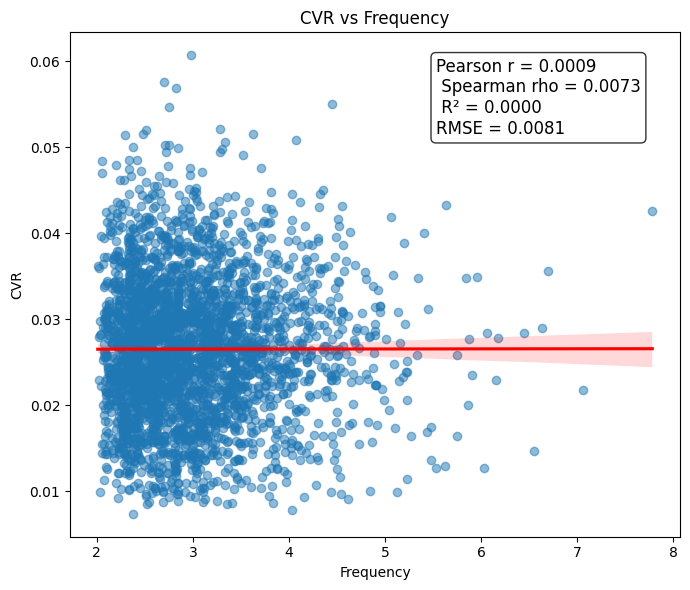

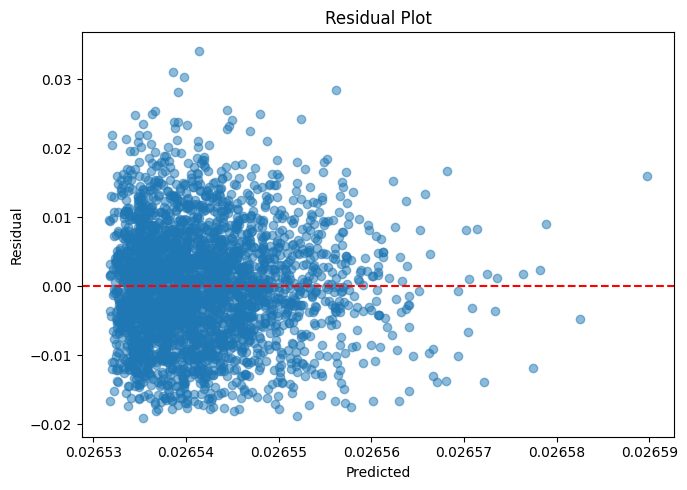


Interpretation
--------------------
Relationship Strength : Very Weak
Direction             : Positive
Pearson correlation is NOT statistically significant.
Spearman correlation is NOT statistically significant.

Approximately 0.0% of the variation in CVR is explained by Frequency.


In [26]:
analyze_relationship(df, "Frequency", "CVR")

### Video-Completion-Rate vs CVR


CVR vs Video_Completion_Rate

Sample Size
--------------------
1207

Descriptive Statistics
--------------------
                        count      mean       std     min     25%     50%  \
Video_Completion_Rate  1207.0  0.575756  0.092228  0.3995  0.5076  0.5903   
CVR                    1207.0  0.026356  0.007889  0.0078  0.0211  0.0264   

                          75%     max  
Video_Completion_Rate  0.6466  0.7410  
CVR                    0.0314  0.0521  

Pearson Correlation
--------------------
r       = -0.2024
p-value = 0.000000

Spearman Correlation
--------------------
rho     = -0.1832
p-value = 0.000000

Linear Regression
--------------------
CVR = 0.036323 + (-0.017311) × Video_Completion_Rate
R²   = 0.0410
RMSE = 0.0077


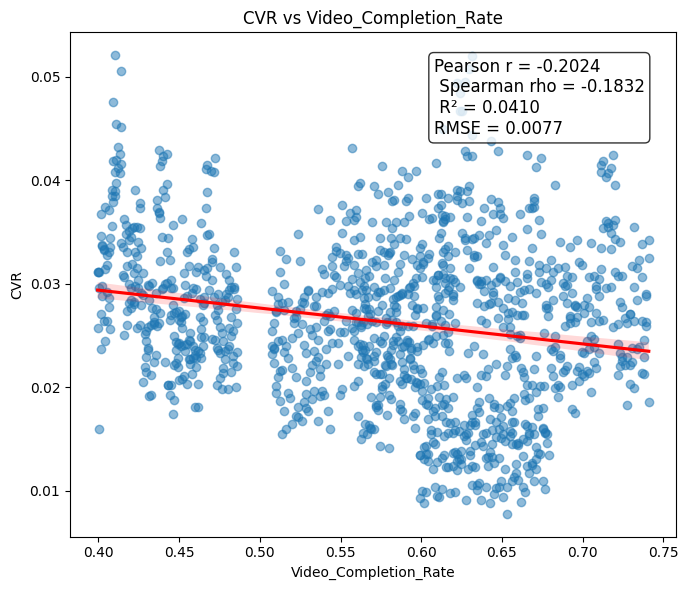

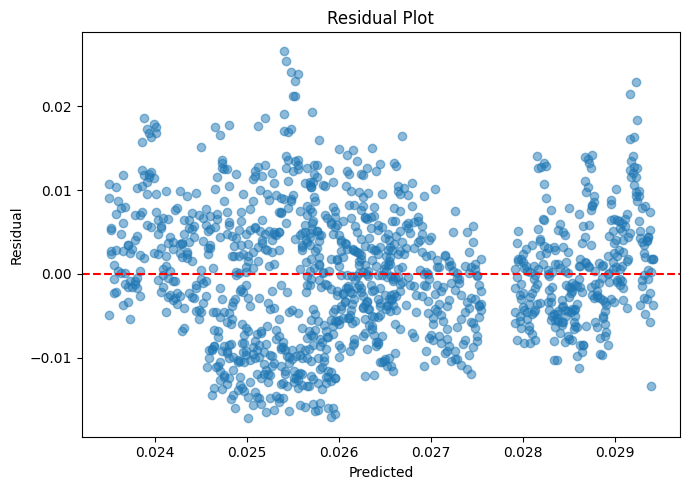


Interpretation
--------------------
Relationship Strength : Weak
Direction             : Negative
Pearson correlation is statistically significant.
Spearman correlation is statistically significant.

Approximately 4.1% of the variation in CVR is explained by Video_Completion_Rate.


In [27]:
analyze_relationship(df, "Video_Completion_Rate", "CVR")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import (
    pearsonr,
    spearmanr,
    shapiro,
    linregress,
    t
)

from sklearn.metrics import (
    r2_score,
    mean_squared_error
)


def analyze_time_trend(
    df,
    date_col,
    value_col,
    period="week",
    agg="mean",
    figsize=(10,6)
):
    """
    General trend analysis for any time period.

    Parameters
    ----------
    df : DataFrame

    date_col : str
        Date column

    value_col : str
        Variable to analyze

    period :
        day
        week
        month
        quarter
        year

    agg :
        mean
        median
        sum
        count
    """

    # -------------------------------------------------------
    # Prepare Data
    # -------------------------------------------------------

    data = df.copy()

    data[date_col] = pd.to_datetime(data[date_col])

    if period == "day":
        data["_period"] = data[date_col].dt.dayofyear

    elif period == "week":
        data["_period"] = (
            data[date_col]
            .dt.isocalendar()
            .week
            .astype(int)
        )

    elif period == "month":
        data["_period"] = data[date_col].dt.month

    elif period == "quarter":
        data["_period"] = data[date_col].dt.quarter

    elif period == "year":
        data["_period"] = data[date_col].dt.year

    else:
        raise ValueError("Invalid period.")

    trend = (
        data
        .groupby("_period")[value_col]
        .agg(agg)
        .reset_index()
    )

    x = trend["_period"].values.astype(float)
    y = trend[value_col].values.astype(float)

    # -------------------------------------------------------
    # Correlations
    # -------------------------------------------------------

    pearson_r, pearson_p = pearsonr(x, y)

    spearman_rho, spearman_p = spearmanr(x, y)

    # -------------------------------------------------------
    # Linear Regression
    # -------------------------------------------------------

    regression = linregress(x, y)

    slope = regression.slope
    intercept = regression.intercept

    r_value = regression.rvalue
    p_value = regression.pvalue
    stderr = regression.stderr

    y_pred = intercept + slope * x

    r2 = r2_score(y, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y, y_pred)
    )

    # -------------------------------------------------------
    # Confidence Interval (Slope)
    # -------------------------------------------------------

    alpha = 0.05

    dfree = len(x) - 2

    t_value = t.ppf(
        1 - alpha/2,
        dfree
    )

    slope_lower = slope - t_value * stderr
    slope_upper = slope + t_value * stderr

    # -------------------------------------------------------
    # Confidence Band
    # -------------------------------------------------------

    x_mean = np.mean(x)

    s_err = np.sqrt(
        np.sum((y - y_pred)**2) / dfree
    )

    conf = (
        t_value *
        s_err *
        np.sqrt(
            1/len(x)
            +
            (x - x_mean)**2 /
            np.sum((x - x_mean)**2)
        )
    )

    lower = y_pred - conf
    upper = y_pred + conf

    # -------------------------------------------------------
    # Scatter Plot
    # -------------------------------------------------------

    plt.figure(figsize=figsize)

    plt.scatter(
        x,
        y,
        s=60,
        alpha=.7,
        label="Observed"
    )

    plt.plot(
        x,
        y_pred,
        color="red",
        linewidth=2,
        label="Best Fit"
    )

    plt.fill_between(
        x,
        lower,
        upper,
        color="red",
        alpha=.20,
        label="95% CI"
    )

    plt.xlabel(period.title())
    plt.ylabel(value_col)

    plt.title(
        f"{value_col} by {period.title()}"
    )

    plt.legend()

    plt.tight_layout()

    plt.show()

    # -------------------------------------------------------
    # Residual Plot
    # -------------------------------------------------------

    residuals = y - y_pred

    plt.figure(figsize=(7,5))

    plt.scatter(
        y_pred,
        residuals
    )

    plt.axhline(
        0,
        linestyle="--",
        color="red"
    )

    plt.xlabel("Predicted")

    plt.ylabel("Residual")

    plt.title("Residual Plot")

    plt.tight_layout()

    plt.show()

    # -------------------------------------------------------
    # Residual Normality
    # -------------------------------------------------------

    shapiro_stat, shapiro_p = shapiro(
        residuals
    )

    # -------------------------------------------------------
    # Output
    # -------------------------------------------------------

    print("="*80)
    print(f"{value_col} by {period.title()}")
    print("="*80)

    print("\nAggregated Data")
    print("----------------------------")
    print(trend)

    print("\nPearson Correlation")
    print("----------------------------")
    print(f"r = {pearson_r:.4f}")
    print(f"p = {pearson_p:.6f}")

    print("\nSpearman Correlation")
    print("----------------------------")
    print(f"rho = {spearman_rho:.4f}")
    print(f"p = {spearman_p:.6f}")

    print("\nLinear Regression")
    print("----------------------------")
    print(
        f"{value_col} = "
        f"{intercept:.6f} + ({slope:.6f}) × {period}"
    )

    print(f"R²      = {r2:.4f}")
    print(f"RMSE    = {rmse:.4f}")
    print(f"p-value = {p_value:.6f}")

    print("\n95% Confidence Interval (Slope)")
    print("----------------------------")
    print(f"[{slope_lower:.6f}, {slope_upper:.6f}]")

    print("\nResidual Normality")
    print("----------------------------")
    print(f"Shapiro p = {shapiro_p:.6f}")

    print("\nInterpretation")
    print("----------------------------")

    if p_value < 0.05:

        if slope > 0:

            print(
                f"{value_col} shows a statistically "
                f"significant increasing trend over time."
            )

        else:

            print(
                f"{value_col} shows a statistically "
                f"significant decreasing trend over time."
            )

    else:

        print(
            "No statistically significant trend was detected."
        )

    return trend

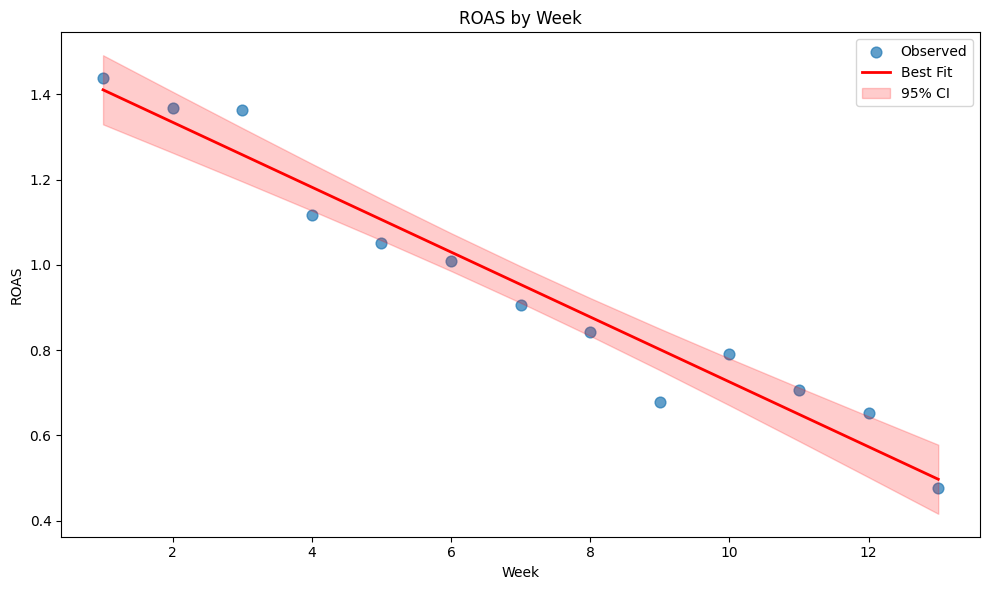

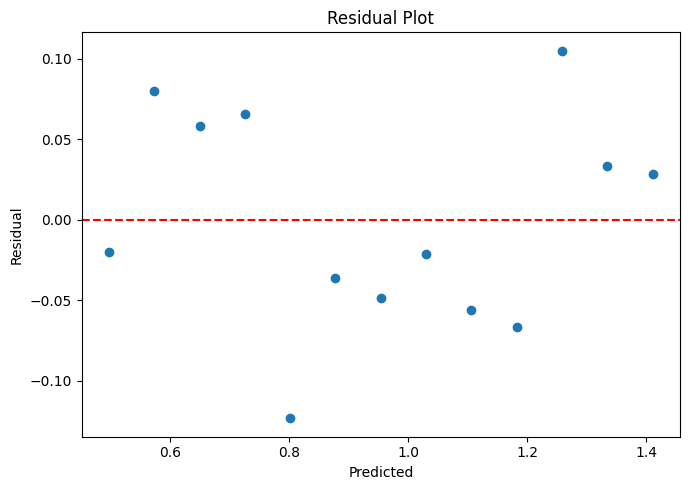

ROAS by Week

Aggregated Data
----------------------------
    _period      ROAS
0         1  1.439280
1         2  1.367828
2         3  1.363397
3         4  1.115910
4         5  1.050275
5         6  1.008630
6         7  0.905398
7         8  0.841684
8         9  0.678227
9        10  0.791334
10       11  0.707324
11       12  0.653218
12       13  0.476880

Pearson Correlation
----------------------------
r = -0.9752
p = 0.000000

Spearman Correlation
----------------------------
rho = -0.9835
p = 0.000000

Linear Regression
----------------------------
ROAS = 1.486741 + (-0.076135) × week
R²      = 0.9510
RMSE    = 0.0646
p-value = 0.000000

95% Confidence Interval (Slope)
----------------------------
[-0.087599, -0.064671]

Residual Normality
----------------------------
Shapiro p = 0.824009

Interpretation
----------------------------
ROAS shows a statistically significant decreasing trend over time.


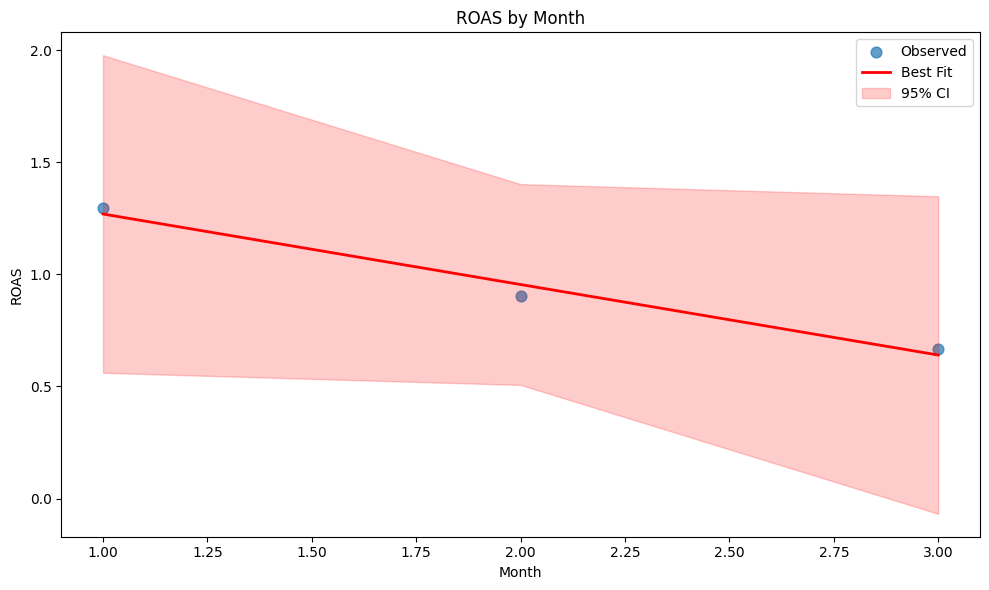

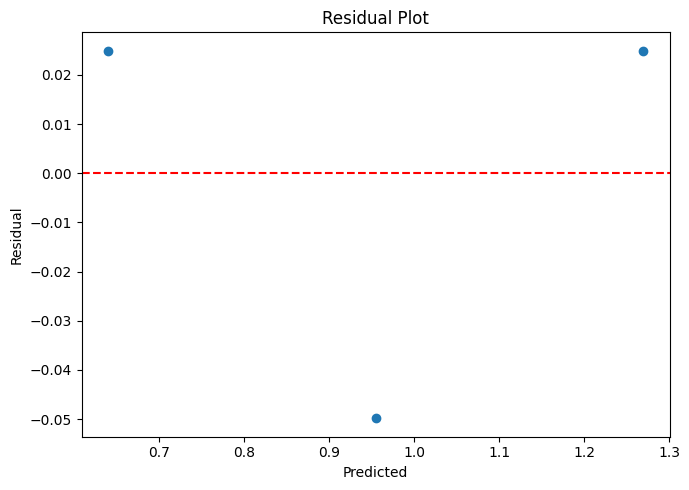

ROAS by Month

Aggregated Data
----------------------------
   _period      ROAS
0        1  1.294138
1        2  0.904816
2        3  0.665056

Pearson Correlation
----------------------------
r = -0.9907
p = 0.086842

Spearman Correlation
----------------------------
rho = -1.0000
p = 0.000000

Linear Regression
----------------------------
ROAS = 1.583751 + (-0.314541) × month
R²      = 0.9815
RMSE    = 0.0353
p-value = 0.086842

95% Confidence Interval (Slope)
----------------------------
[-0.863129, 0.234048]

Residual Normality
----------------------------
Shapiro p = 0.000000

Interpretation
----------------------------
No statistically significant trend was detected.


,_period,ROAS
0,1,1.294138
1,2,0.904816
2,3,0.665056


In [ ]:
# Weekly average ROAS
analyze_time_trend(
    df,
    "Date",
    "ROAS",
    period="week"
)

# Monthly average Revenue
analyze_time_trend(
    df,
    "Date",
    "ROAS",
    period="month"
)





In [ ]:
!pip install --upgrade scipy
!pip install --upgrade statsmodels